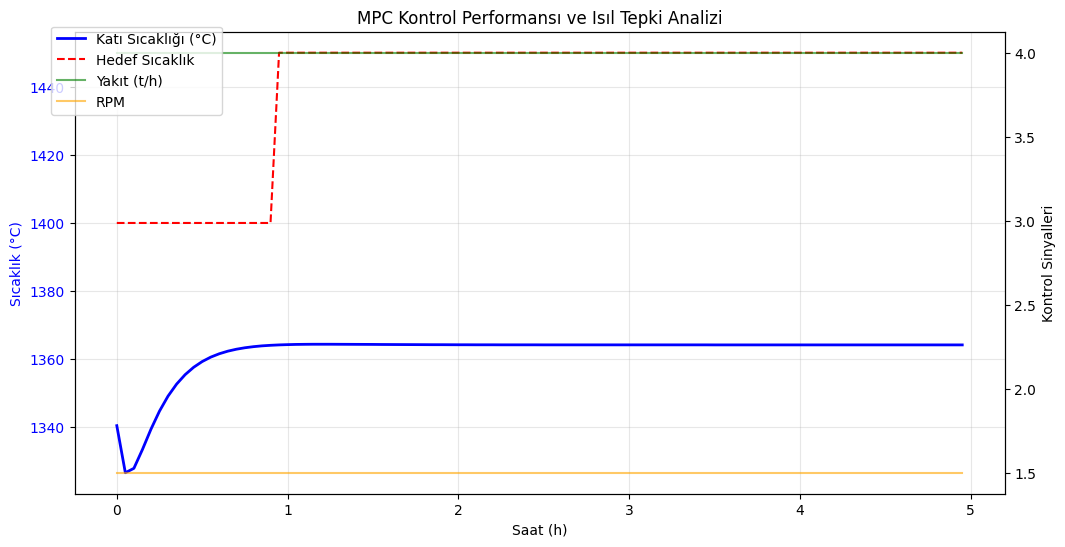

Ortalama Mutlak Hata (MAE): 78.58 °C
Maksimum Hata: 85.81 °C


In [1]:
# %% [markdown]
# # Fırın MPC Performans Analizi
# Bu analiz, MPC kontrolcüsünün set-point değişimine tepkisini ve fırın sıcaklık kararlılığını inceler.

# %%
import pandas as pd
import matplotlib.pyplot as plt

# CSV verisini yükle
df = pd.read_csv('control.csv')

# Görselleştirme
fig, ax1 = plt.subplots(figsize=(12, 6))

# Sol eksen: Sıcaklıklar
ax1.plot(df['Time'], df['Ts_burning'], label='Katı Sıcaklığı (°C)', color='blue', linewidth=2)
ax1.plot(df['Time'], df['Target'], label='Hedef Sıcaklık', linestyle='--', color='red')
ax1.set_xlabel('Saat (h)')
ax1.set_ylabel('Sıcaklık (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Sağ eksen: Yakıt ve RPM
ax2 = ax1.twinx()
ax2.plot(df['Time'], df['Fuel'], label='Yakıt (t/h)', color='green', alpha=0.6)
ax2.plot(df['Time'], df['RPM'], label='RPM', color='orange', alpha=0.6)
ax2.set_ylabel('Kontrol Sinyalleri', color='black')

plt.title('MPC Kontrol Performansı ve Isıl Tepki Analizi')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

# %% [markdown]
# ### Performans Metrikleri
# MPC'nin set-point'e ulaşma başarısını ölçüyoruz.
# %%
# Hata (Error) analizi
df['Error'] = abs(df['Ts_burning'] - df['Target'])
mean_error = df['Error'].mean()
max_error = df['Error'].max()

print(f"Ortalama Mutlak Hata (MAE): {mean_error:.2f} °C")
print(f"Maksimum Hata: {max_error:.2f} °C")